# BTSP on a linear track

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* Linear track (periodic)
* Agent navigates in a specific direction (and eventually back and forth)
* Target object located partway along the track.
* Two-compartment pyramidal neuron layer:
  * Somatic input: uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
import importlib
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, plot_fcts, run_manager
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, hyper_util, plot_util, params_util, animate_util, gen_util, learn_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "linear_track"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Hyperparameters and functions

In [5]:
NUM_STEPS = 3800
USE_HEBBIAN = False

target_position = np.asarray([params_util.SCALE_LINEAR * 3 / 5])

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=target_position,
    wait_at_end=int(15 / params_util.DT),
)

Pyr_params = params_util.get_Pyr_params(
    environment="linear",
    log_BTSP=True,
)

## 1. Initial direction

 16%|██████▎                                | 614/3800 [00:00<00:04, 755.29it/s]

BTSP event recorded for neuron 0 at step 516 (15.48 sec).


 34%|████████████▉                         | 1299/3800 [00:01<00:03, 709.86it/s]

BTSP update applied to neuron 0 at step 1210 (36.30 sec).


100%|██████████████████████████████████████| 3800/3800 [00:05<00:00, 713.80it/s]


Finishing last trajectory.


993it [00:01, 684.01it/s]


Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 28.76 +/- 15.39 sec each
Trajectory lengths (5) to date: 958.80 +/- 512.88 steps each
1 BTSP events triggered (allowed from steps 0 to 4793): occurred at step 516.


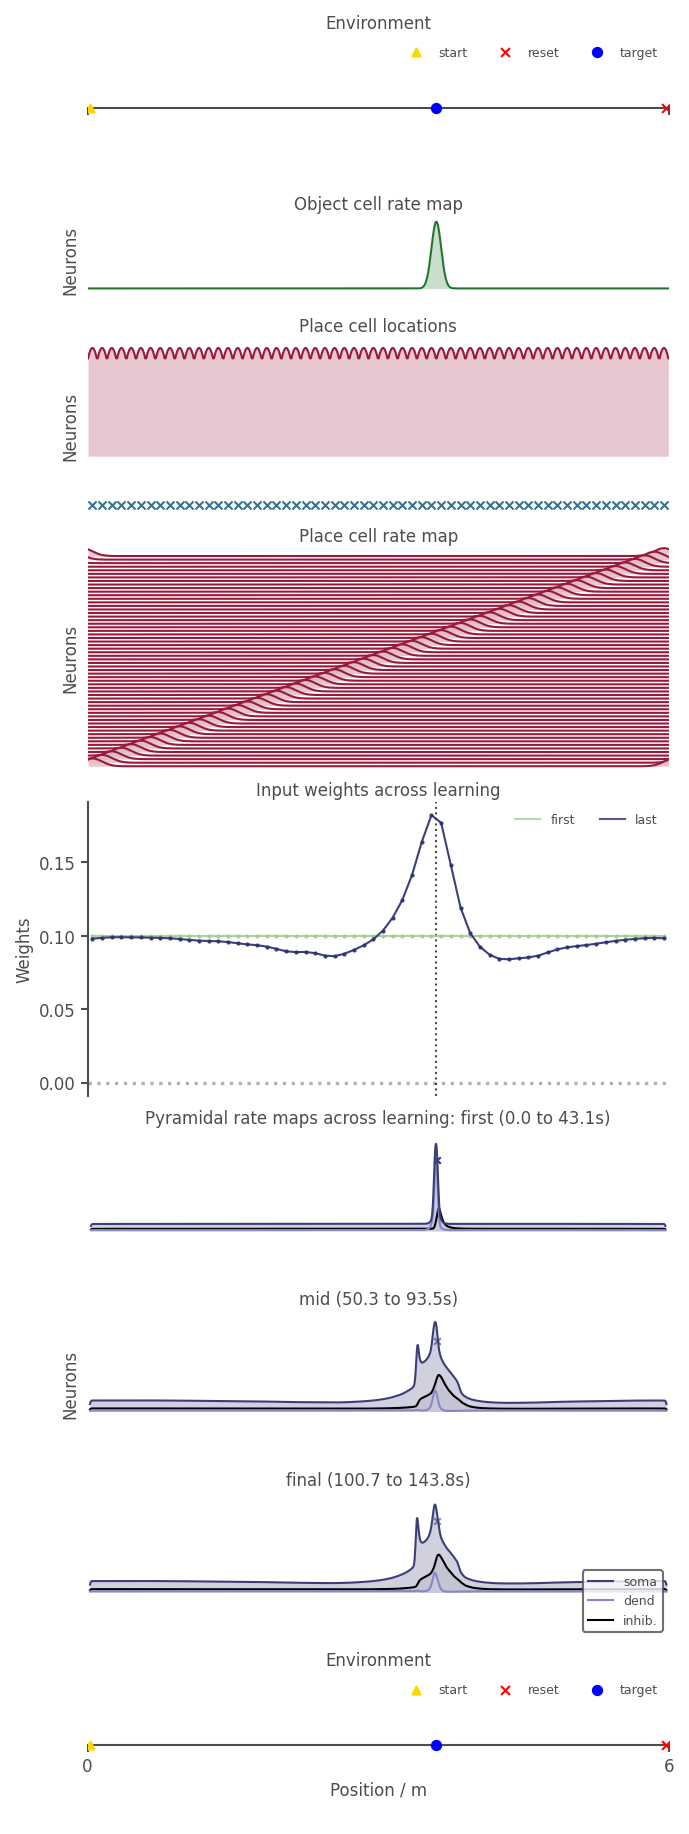

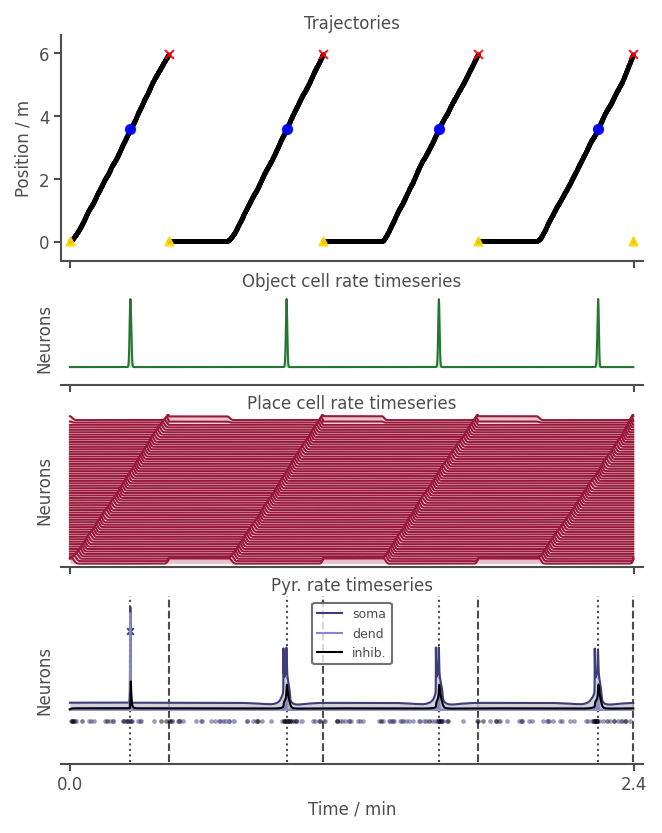

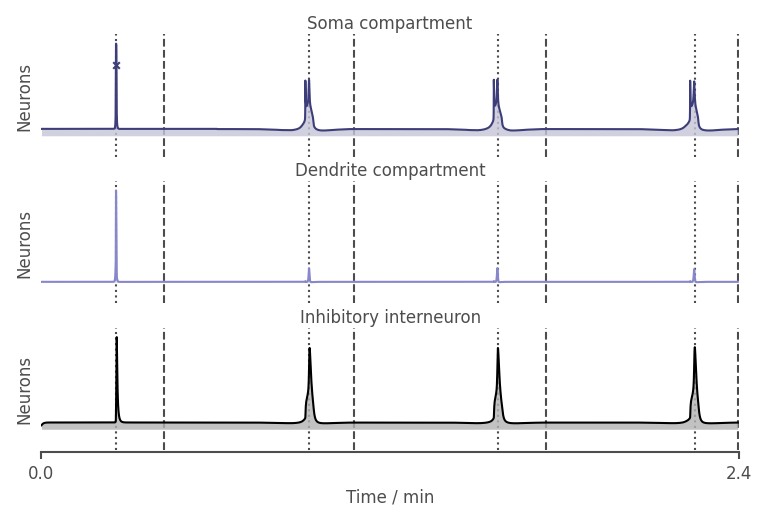

In [6]:
learner, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
    agent_params=agent_params,
    Pyr_params=Pyr_params,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
)

Pyrs = learner.Pyrs
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)

ts_axes = learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["1-initial_spatial"] = spatial_axes
ALL_FIGURES["1-initial_time"] = time_axes
ALL_FIGURES["1-initial_timeseries"] = ts_axes

In [7]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
No neuron had at least two BTSP events triggered.


Speed mean: 24.08 cm/s, std: 4.11 cm/s.


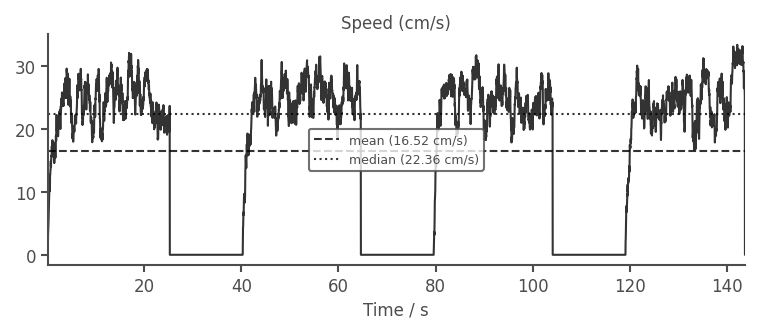

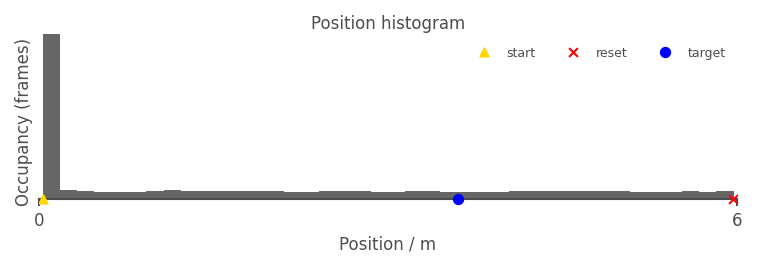

In [8]:
learner.Agent.log_speed_stats(ignore_near_zero=True)
sub_ax_speed = learner.Agent.plot_speed(mark_median=True, mark_mean=True)
sub_ax_occ = learner.Agent.plot_occupancy()

ALL_FIGURES["1-single_speed"] = sub_ax_speed
ALL_FIGURES["1-single_occupancy"] = sub_ax_occ

### Initial direction track groundtruth rate maps

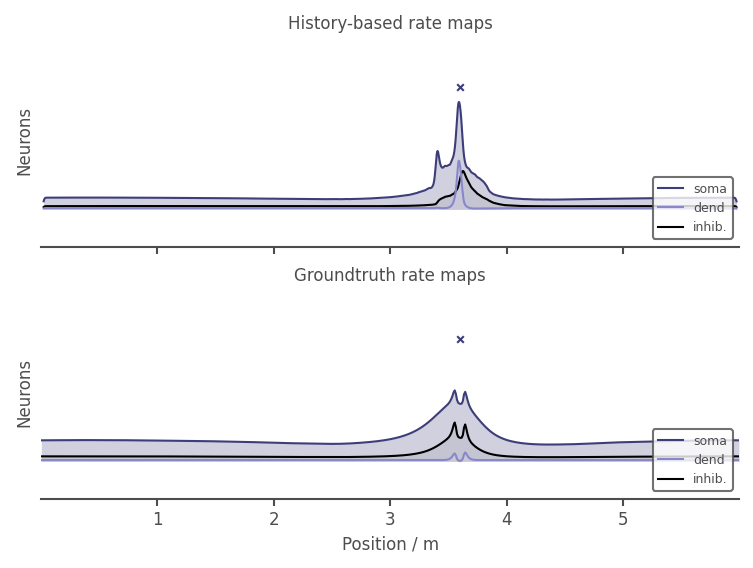

In [9]:
_, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps");

ALL_FIGURES["1-initial_rate_maps"] = ax1D

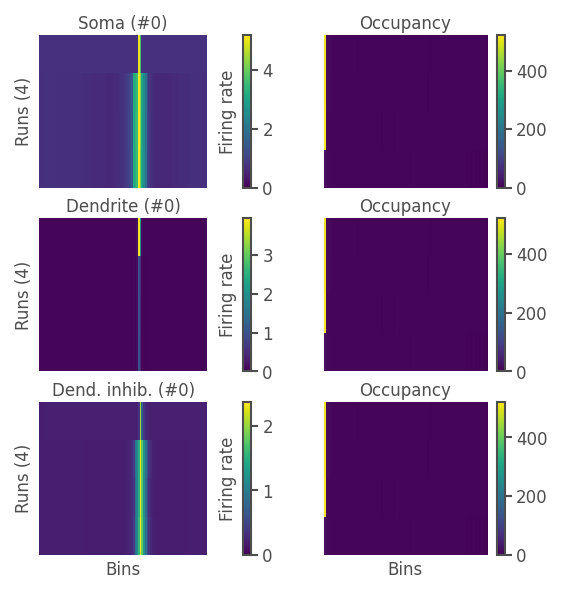

In [10]:
axes = learner.Pyrs.plot_binned_rates()

ALL_FIGURES["1-initial_binned_rates"] = axes

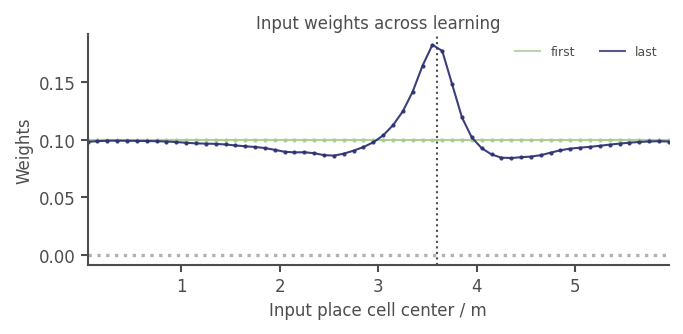

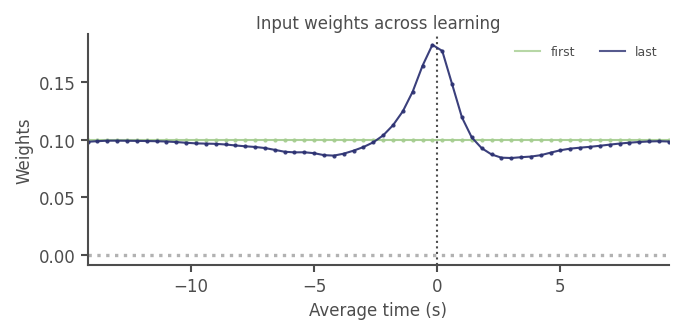

In [11]:
ws = [learner.Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["1-initial_weights"] = sub_ax
ALL_FIGURES["1-initial_weights_time"] = sub_ax_time

### Assessments based on theoretical kernel

Update 1 regul.: 0.9061 (w)


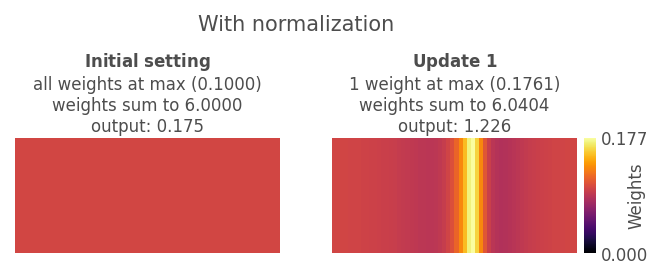

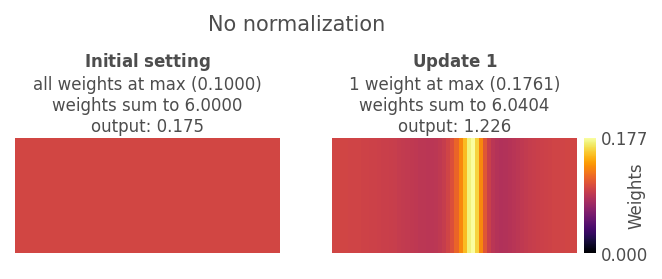

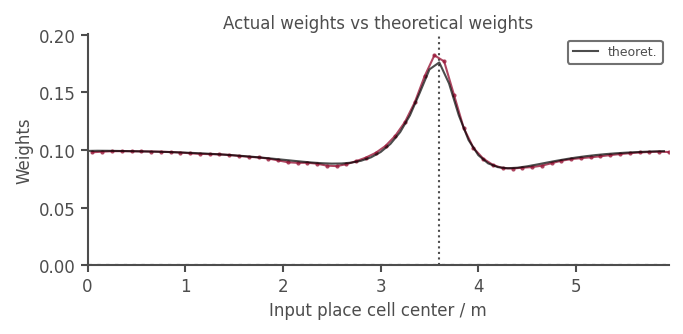

In [12]:
norm_theor_axes, no_norm_theor_axes, comp_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    Pyrs.SomaCompartment,
    output_fr=4.2, # arbitrary, but works well
)

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_weights_compared"] = comp_sub_ax

### Initial direction inputs and activations

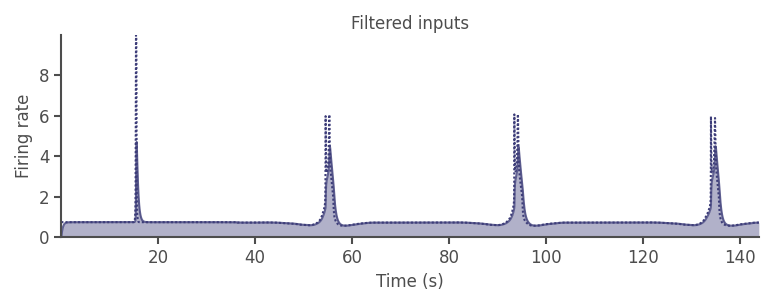

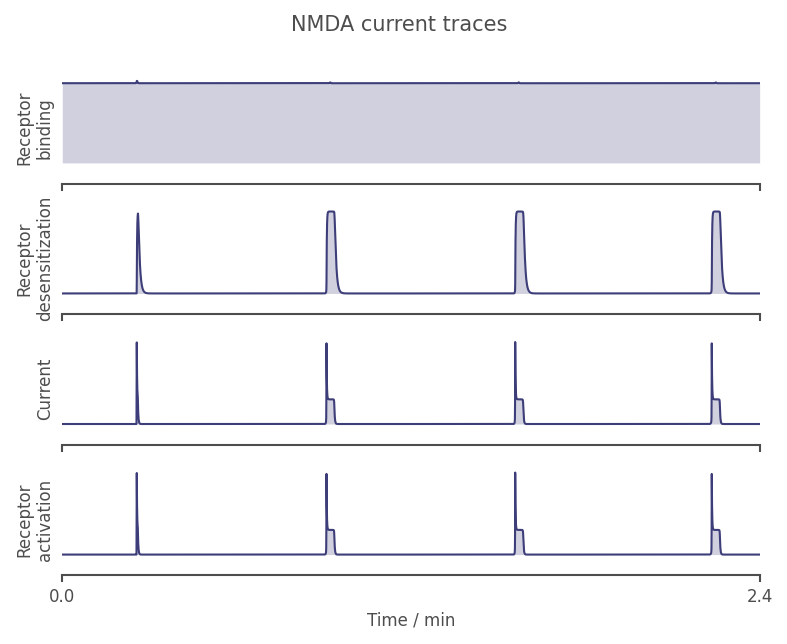

In [13]:
sub_ax, _ = learner.Pyrs.DendriteInhibition.plot_filtered("Pyr_TwoComp_soma")
ax1D = learner.Pyrs.SomaCompartment.NMDACurrent.plot_timeseries(datatypes="all")

ALL_FIGURES["1-initial_filtered_inputs"] = sub_ax
ALL_FIGURES["1-initial_NMDA_current"] = ax1D

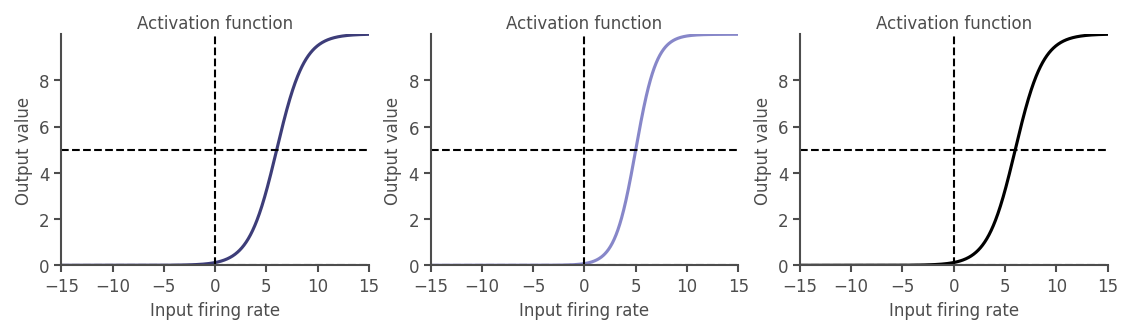

In [14]:
fig, ax1D = plt.subplots(1, 3, figsize=[9, 2])
learner.Pyrs.SomaCompartment.plot_activation_function(sub_ax=ax1D[0])
learner.Pyrs.DendriteCompartment.plot_activation_function(sub_ax=ax1D[1])
learner.Pyrs.DendriteInhibition.plot_activation_function(sub_ax=ax1D[2])

ALL_FIGURES["activation"] = ax1D

### Initial direction BTSP stats

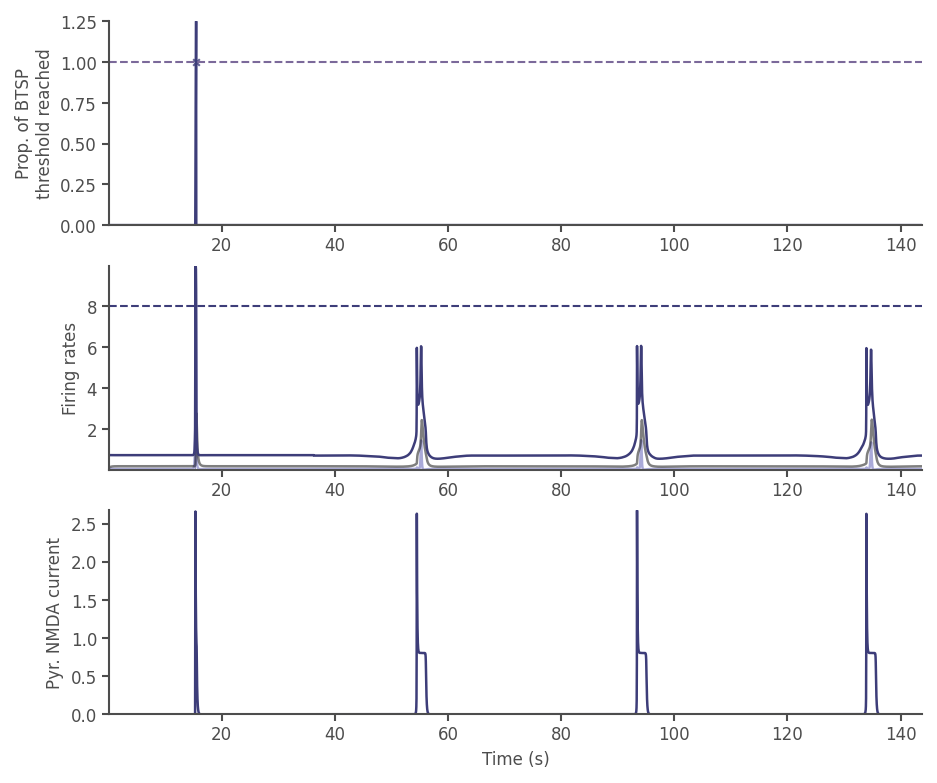

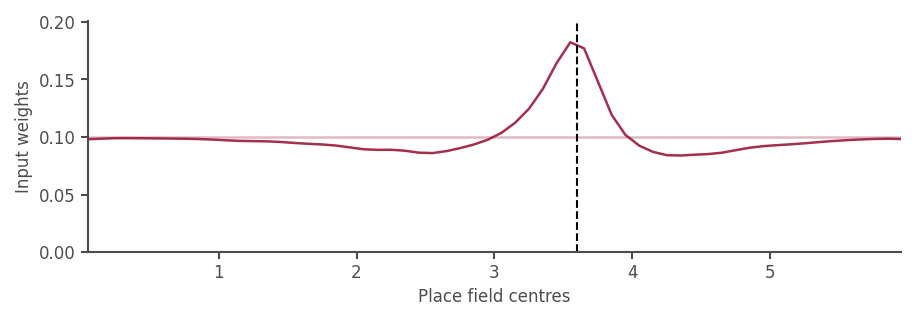

In [15]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner.Pyrs, 
    recorded_weights=learner.get_recorded_weights(), 
    target_position=target_position
)

ALL_FIGURES["1-initial_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["1-initial_PC_weights"] = PCs_sub_ax

### Pre BTSP kernel

#### Plot eligibility trace equivalent

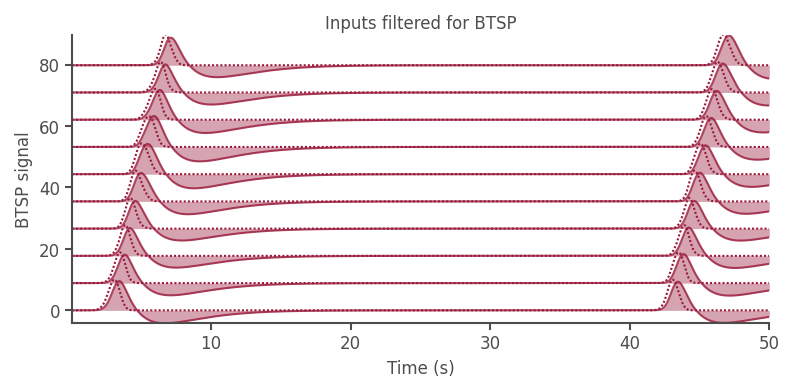

In [16]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs", t_end=50, chosen_neurons=np.arange(5, 15))
ALL_FIGURES["1-initial_pre_BTSP_filter"] = sub_ax

### Post BTSP kernel

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696).


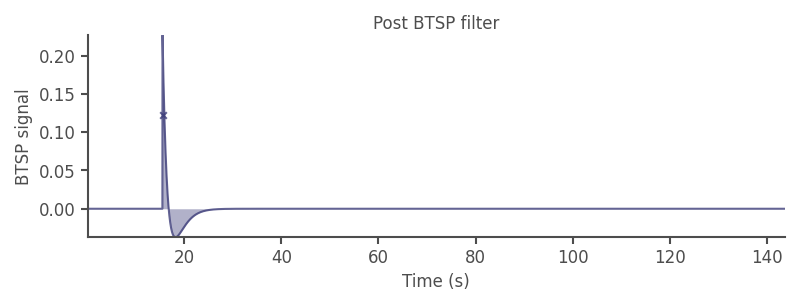

In [17]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["1-initial_post_BTSP_filter"] = sub_ax

## 2. Move target
Target moved to a new location after initial BTSP learning.

 24%|█████████▌                             | 926/3800 [00:01<00:04, 702.02it/s]

BTSP event recorded for neuron 0 at step 25238 (757.14 sec).


 44%|████████████████▊                     | 1687/3800 [00:02<00:02, 758.89it/s]

BTSP update applied to neuron 0 at step 25932 (777.96 sec).


100%|██████████████████████████████████████| 3800/3800 [00:05<00:00, 670.37it/s]


...

BTSP update applied to neuron 0 at step 33714 (1011.42 sec).


100%|██████████████████████████████████████| 3800/3800 [00:05<00:00, 752.31it/s]


Finishing last trajectory.


117it [00:00, 713.13it/s]


Only reached target 3 times (target: 10).
Trajectory lengths (29) to date: 37.39 +/- 7.52 sec each
Trajectory lengths (29) to date: 1246.45 +/- 250.79 steps each
1 BTSP events triggered (allowed from steps 32229 to 36146): occurred at step 33020.


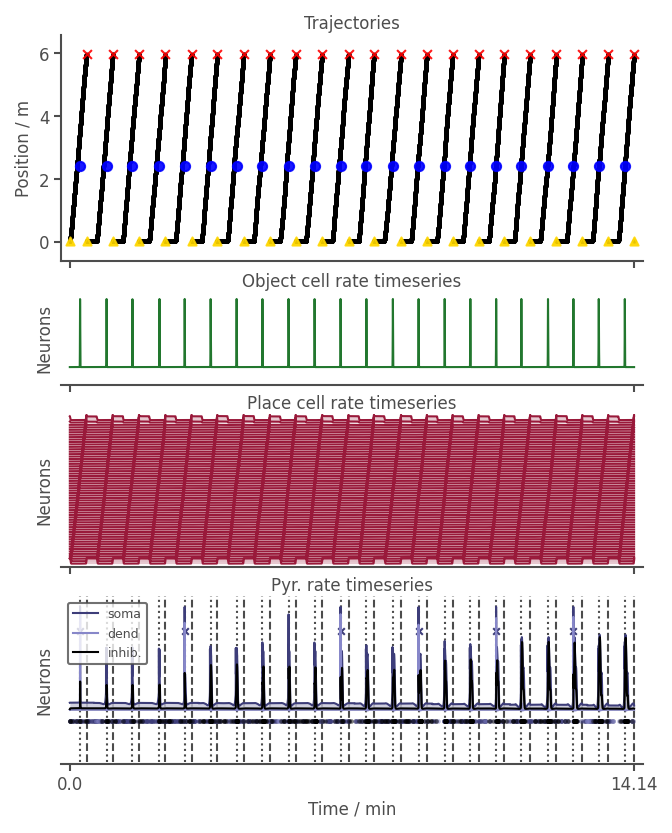

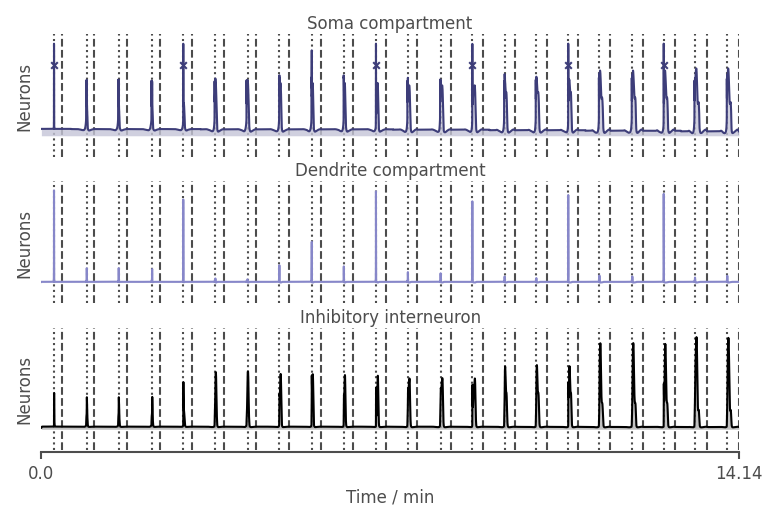

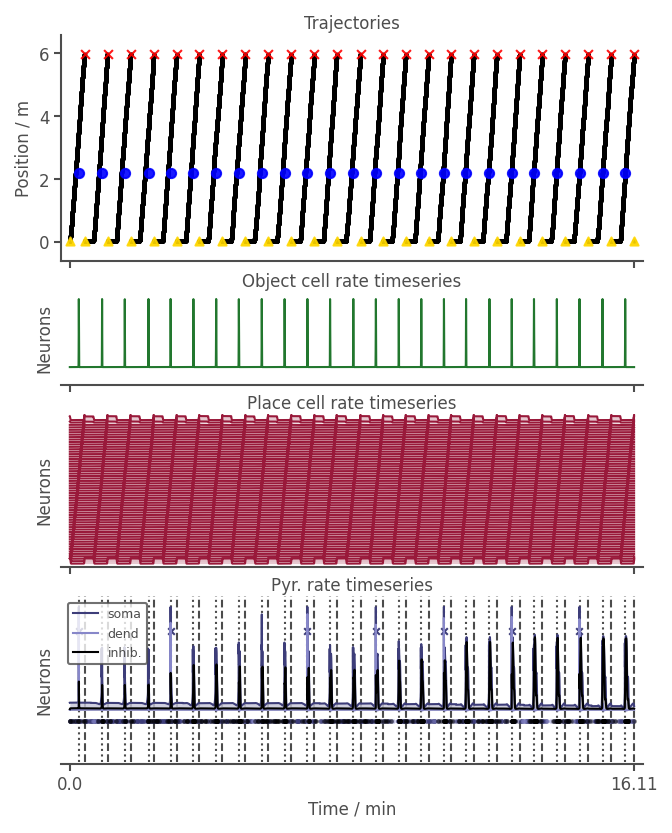

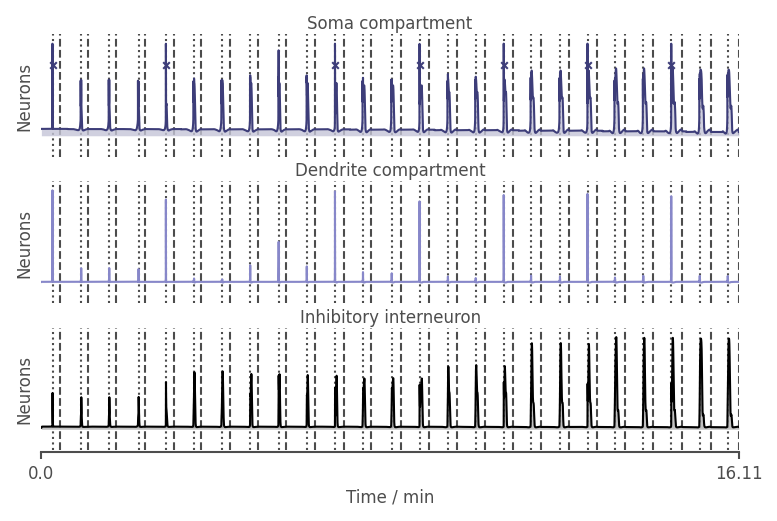

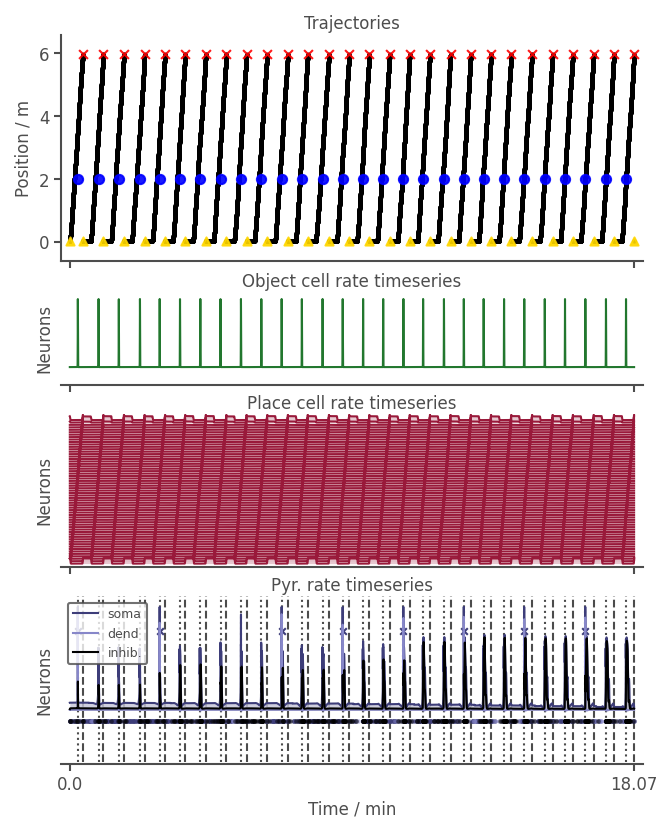

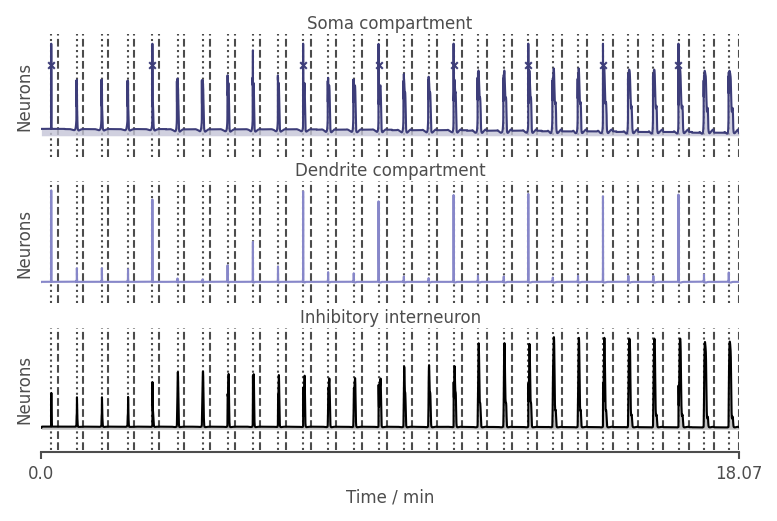

In [23]:
for i in range(6, 9):
    CLOSE = 0.2
    MID = 0.9
    FAR = 2.0
    moved_target_position = target_position - CLOSE * i
    
    move_time = Ag.t
    Ag.set_target_position(moved_target_position)
    
    learner_moved = run_manager.learn_1D_BTSP(
        Pyrs=Pyrs,
        use_Hebbian=USE_HEBBIAN,
        BTSP_on=0,
        max_num_steps=NUM_STEPS,
        plot=False
    )
    
    time_axes = plot_fcts.plot_1D_time_info(learner_moved.Pyrs)
    ts_axes = learner_moved.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")
    
    ALL_FIGURES["2-moved_time"] = time_axes
    ALL_FIGURES["2-moved_timeseries"] = ts_axes

### Moved target groundtruth rate maps

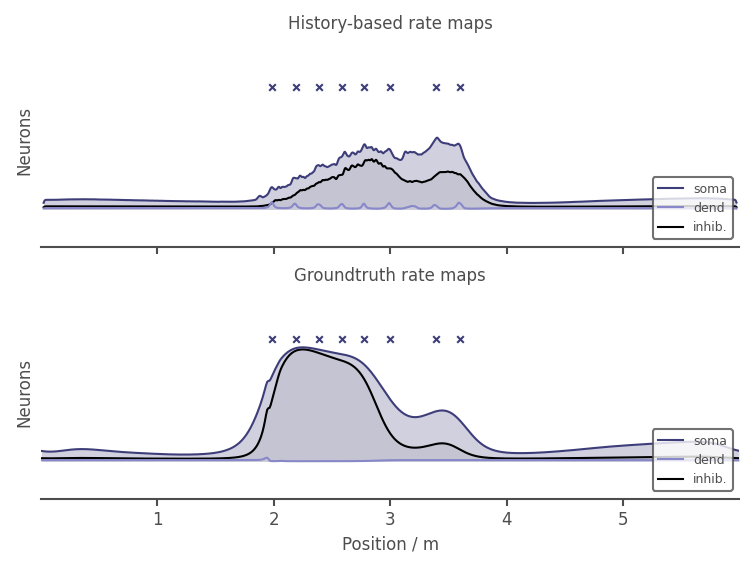

In [24]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner_moved.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner_moved.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps")

ALL_FIGURES["2-moved_rate_maps"] = ax1D

### Moved target BTSP stats

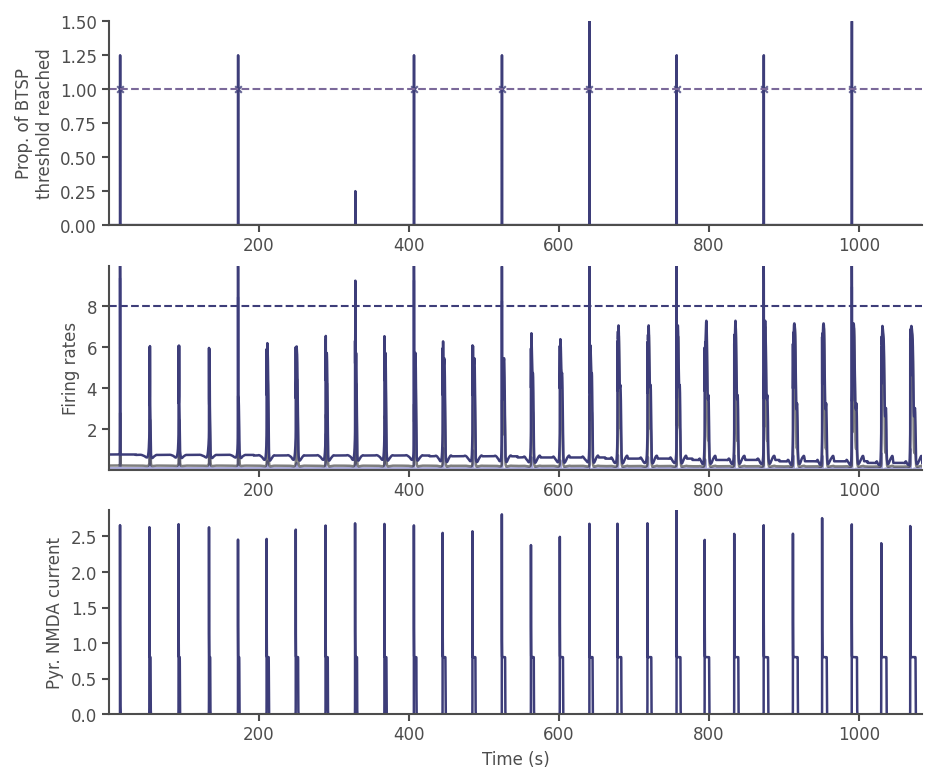

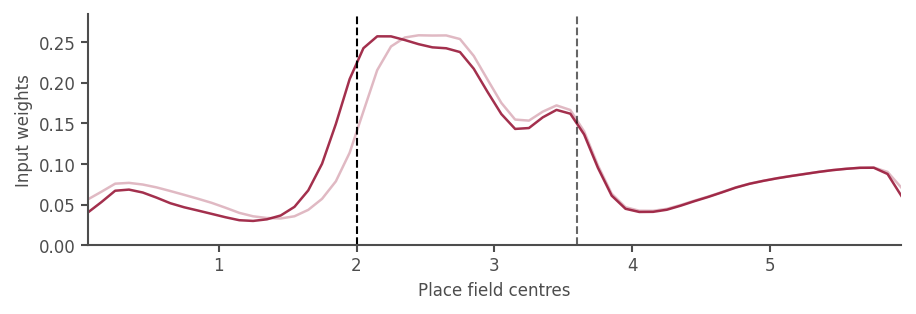

In [25]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner_moved.Pyrs, 
    recorded_weights=learner_moved.get_recorded_weights(),
    target_position=moved_target_position, 
    other_positions=[target_position]
)

ALL_FIGURES["2-moved_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["2-moved_PC_weights"] = PCs_sub_ax

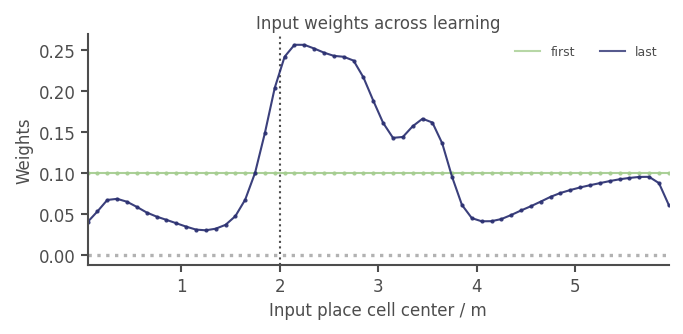

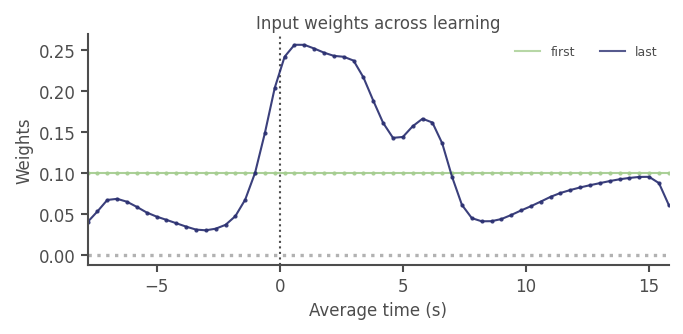

In [26]:
ws = [learner_moved.Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner_moved.Pyrs.SomaCompartment.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner_moved.Pyrs.SomaCompartment.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["2-moved_weights"] = sub_ax
ALL_FIGURES["2-moved_weights_time"] = sub_ax_time

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696, 696, 696, 696, 696, 696, 696, 696).


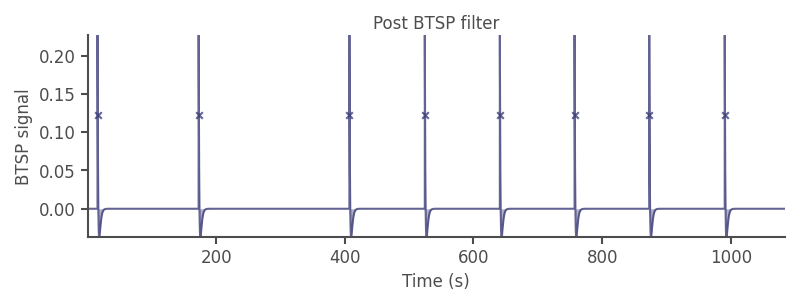

In [27]:
learner_moved.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_moved.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["2-moved_post_BTSP_filter"] = sub_ax

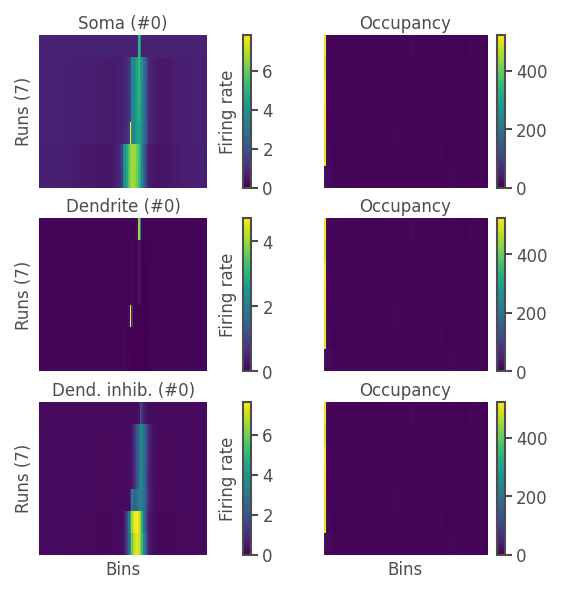

In [99]:
axes = learner_moved.Pyrs.plot_binned_rates()
ALL_FIGURES["2-moved_binned_rates"] = axes

## 3. Switch to back and forth navigation
Agent set to travel back and forth along the track.

100%|██████████████████████████████████████| 7600/7600 [00:10<00:00, 692.04it/s]


Finishing last trajectory.


5558it [00:07, 705.61it/s]


Reached target 10 times.
Trajectory lengths (18) to date: 36.43 +/- 9.51 sec each
Trajectory lengths (18) to date: 1214.50 +/- 316.98 steps each
0 BTSP events triggered (allowed from steps 8702 to 21860).


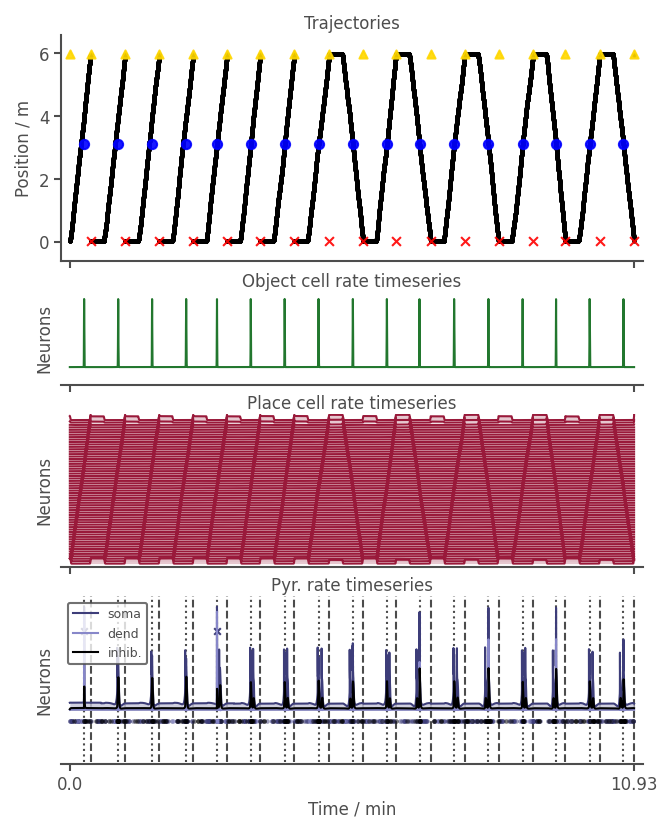

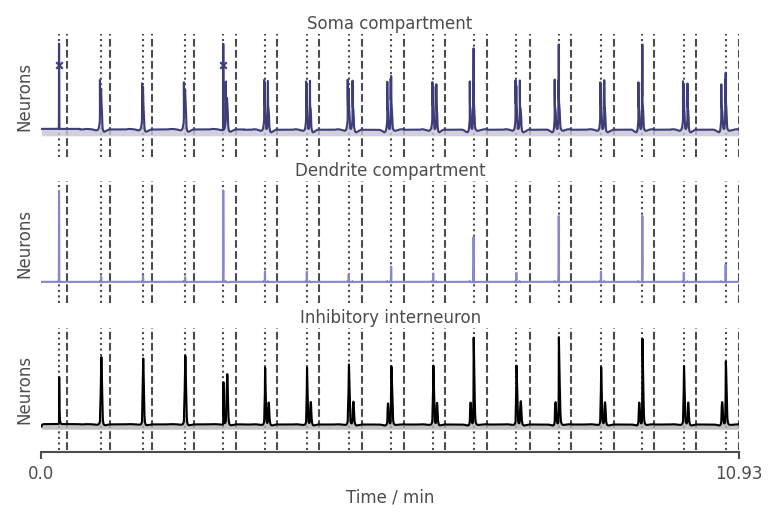

In [27]:
bf_start_time = Ag.t
BF_NUM_STEPS = int(NUM_STEPS * 2)

learner_bf = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=BF_NUM_STEPS,
    reverse=True,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_bf.Pyrs)
ts_axes = learner_bf.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["3-back_forth_time"] = time_axes
ALL_FIGURES["3-back_forth_timeseries"] = ts_axes

### Back and forth track groundtruth rate maps

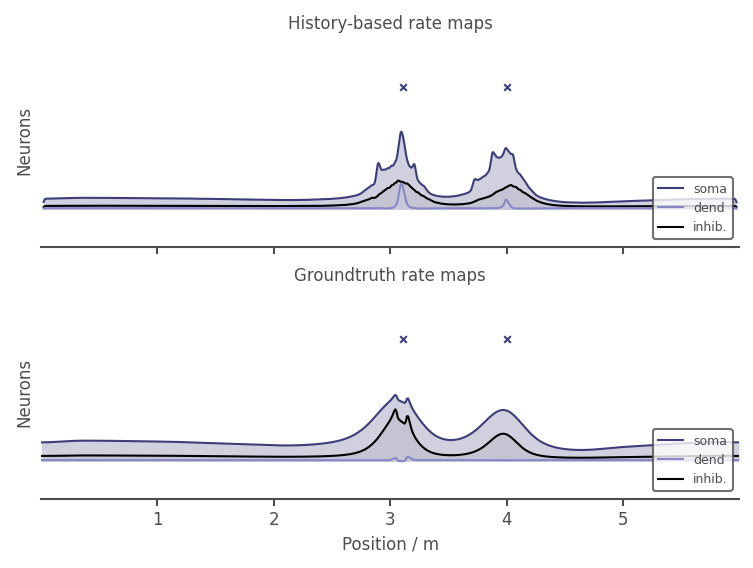

In [28]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner_bf.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner_bf.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps")

ALL_FIGURES["3-back_forth_rate_maps"] = ax1D

In [29]:
learner_bf.Pyrs.SomaCompartment.get_normalization_value_dict()["PCs"]

KeyError: 'PCs'

### Back and forth track BTSP stats

In [ ]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner_bf.Pyrs, 
    recorded_weights=learner_bf.get_recorded_weights(),
    target_position=moved_target_position, 
    other_positions=[target_position]
)

ALL_FIGURES["3-back_forth_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["3-back_forth_PC_weights"] = PCs_sub_ax

In [ ]:
learner_bf.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_bf.Pyrs.SomaCompartment.plot_filtered_for_BTSP()

ALL_FIGURES["3-back_forth_post_BTSP_filter"] = sub_ax

In [ ]:
axes = learner_bf.Pyrs.plot_binned_rates()

ALL_FIGURES["3-back_forth_binned_rates"] = axes

## 4. Remove object from track
Object removed from track.

In [ ]:
pre_removed_time = Ag.t
learner_pre_removed = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    num_trajectories=4,
    max_num_steps=NUM_STEPS * 2, # excess
    plot=False
)

print("\nTarget removed.")
Ag.set_target_position(None)
Objs.set_to_dummy()
removed_time = Ag.t
        
learner_post_removed = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_post_removed.Pyrs)
ts_axes = learner_post_removed.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["4-removed_time"] = time_axes
ALL_FIGURES["4-removed_timeseries"] = ts_axes

In [ ]:
ws = [Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, Pyrs.SomaCompartment.inputs["PCs"]["layer"])

ALL_FIGURES["4-removed_weights"] = sub_ax

In [ ]:
axes = Pyrs.plot_binned_rates()

ALL_FIGURES["4-removed_binned_rates"] = axes

## Before / After

In [ ]:
axes = plot_fcts.plot_pre_post_responses(Pyrs, Objs, ref_time=removed_time, pre=2.5 * 60)
ALL_FIGURES["4-removed_pre_post"] = axes

In [ ]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=False)

pre = 2.5 * 60
pts_btw = 100
all_ylims = [(-0.02, 0.2), None]

for i, ylims in enumerate(all_ylims):
    plot_fcts.plot_pre_post_dendrite_peaks(
        Pyrs, 
        ref_time=removed_time, 
        pre=pre,
        ylims=ylims,
        together=True, 
        label="target removed", 
        ax=ax1D[i],
        pts_btw=pts_btw
    )

ALL_FIGURES["4-removed_pre_post_dendrite"] = ax1D

## 6. Change running speed

In [ ]:
def get_speed(speed="slow"):
    
    base_num_steps = NUM_STEPS * 4
    if speed == "slow":
        speed_mean = params_util.SPEED_MEAN_LINEAR / 1.5
        speed_std = params_util.SPEED_MEAN_LINEAR / 8
        num_steps_use = int(base_num_steps * 1.5)
    elif speed == "fast":
        speed_mean = params_util.SPEED_MEAN_LINEAR * 1.5
        speed_std = params_util.SPEED_MEAN_LINEAR / 16
        num_steps_use = int(base_num_steps / 1.5)
    elif speed == "variable":
        speed_mean = params_util.SPEED_MEAN_LINEAR
        speed_std = params_util.SPEED_MEAN_LINEAR
        num_steps_use = base_num_steps
    else:
        raise ValueError(f"speed {speed} not recognized.")

    return speed_mean, speed_std, num_steps_use

In [ ]:
speed_learners_all = list()
for i, speed in enumerate(["slow", "fast", "variable"]):
    space = "\n" if i > 0 else ""
    print(f"{space}Running at {speed} speed.")

    speed_mean, speed_std, num_steps_use = get_speed(speed)
    speed_target_position = np.asarray([params_util.SCALE_LINEAR / 2])
    agent_params_speed = params_util.get_agent_params(
        environment="linear",
        target_position=speed_target_position,
        speed_mean=speed_mean,
        speed_std=speed_std,
    )
    
    speed_learner, spatial_axes_speed, time_axes_speed = run_manager.learn_1D_BTSP(
        agent_params=agent_params_speed,
        Pyr_params=Pyr_params,
        use_Hebbian=USE_HEBBIAN,
        BTSP_on=0,
        max_num_steps=num_steps_use,
        num_target_reaches=16,
    )
    speed_learners_all.append(speed_learner)
    
    speed_learner.Agent.log_speed_stats(ignore_near_zero=True)
    
    ts_axes_speed = speed_learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")
   
    BTSP_ramp_ax1D_speed, PCs_sub_ax_speed = plot_fcts.plot_1D_BTSP_stats(
        speed_learner.Pyrs, 
        recorded_weights=speed_learner.get_recorded_weights(), 
        target_position=speed_target_position
    )

    BTSP_speed_sub_ax = speed_learner.Pyrs.SomaCompartment.plot_around_BTSP(datatype="speed")

    binned_rates_axes = speed_learner.Pyrs.SomaCompartment.plot_binned_rates(vel_sign_smooth=39) # high threshold

    ALL_FIGURES[f"5-spatial_{speed}"] = spatial_axes_speed
    ALL_FIGURES[f"5-time_{speed}"] = time_axes_speed
    ALL_FIGURES[f"5-timeseries_{speed}"] = ts_axes_speed
    ALL_FIGURES[f"5-BTSP_timeseries_{speed}"] = BTSP_ramp_ax1D_speed
    ALL_FIGURES[f"5-PC_weights_{speed}"] = PCs_sub_ax
    ALL_FIGURES[f"5-BTSP_speed_{speed}"] = BTSP_speed_sub_ax
    ALL_FIGURES[f"5-binned_rates_{speed}"] = binned_rates_axes

## 7. Save and animate

### Save figures

In [ ]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

### Animate

In [ ]:
ANIMATE = True

In [ ]:
if ANIMATE:
    all_learners = [
        learner, 
        learner_moved, 
        learner_bf, 
        learner_pre_removed, 
        learner_post_removed
    ]

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in all_learners]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }
    
    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["time"],
        "fps": 8,
        "speed_up": 3,
        "previous_target_positions": [target_position, moved_target_position],
        "target_move_times": [move_time, removed_time],
        "embed_limit": 40.0,
        "autosave": True,
    }
    
    if (Ag.start_position > Ag.reset_position).all():
        Ag.reverse()

In [ ]:
importlib.reload(animate_util)
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=move_time, 
        savename="1-initial_timeseries",
        addendum="initial direction",
        **all_animate_kwargs
        )
    anim

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=move_time, 
        t_end=bf_start_time, 
        savename="2-moved_timeseries",
        addendum="target moved",
        **all_animate_kwargs
        )
    anim

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=bf_start_time, 
        t_end=pre_removed_time, 
        savename="3-back_forth_timeseries",
        addendum="back and forth",
        **all_animate_kwargs
        )
    anim

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=pre_removed_time, 
        t_end=None, 
        savename="4-removed_timeseries",
        addendum="target removed",
        **all_animate_kwargs
        )
    anim

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=None, 
        savename="5-full_timeseries",
        **all_animate_kwargs
        )
    anim